@author Nassir Mohammad

# Preliminaries

In [1]:
import sys 
sys.path.append('../')
sys.path.append('../scripts')

from perception_nassir import Perception
from scripts.utilities import plot_data
from scripts.utilities import apply_methods

import pandas as pd
import numpy as np

image_save_switch = False
image_save_path = ''

# Small univariate data 

## Boris hypothetical dataset 1 - Z-score failure small dataset 

This example illustrates anomaly detection on a hypothetical small dataset
taken from: Boris Iglewicz and David C. Hoaglin. How to Detect and Handle
Outliers, ASQC basic references in quality control, ASQC Quality Press,
1993. The example illustrates the failure of the Z-score methods.


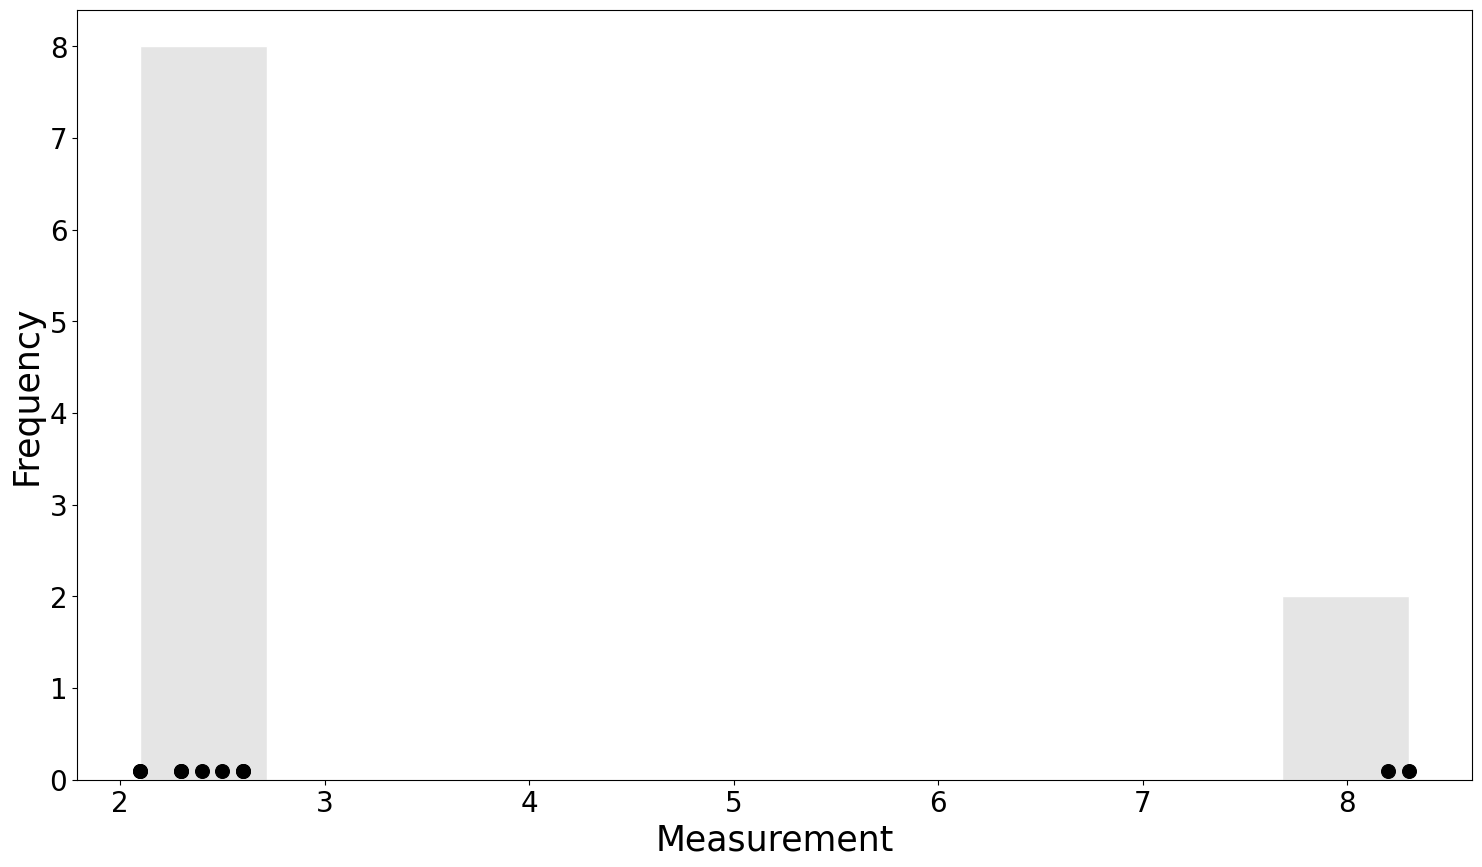

,0,1
perception_method,8.2,8.3
z_score_2_5_method,NaN,NaN
z_score_3_method,NaN,NaN
mad_method,8.2,8.3
iqr_method,8.2,8.3


In [2]:
data = np.array([2.1, 2.6, 2.4, 2.5, 2.3, 2.1, 2.3, 2.6, 8.2, 8.3])
save_path = image_save_path + 'BorisHypo1.png'
plot_data(data, save_path, save_switch=image_save_switch,
          x_label='Measurement', y_label='Frequency')
apply_methods(data)

## Synthetic temperatures with outliers Z-score failure by masking

This example shows a set of temperatures, the first 24, for which none of the methods detect any outliers. We add two numbers that are considered outliers [40, 45]. However, the Z-score method fails to detect the two large outliers. This is due to the Z-score method being heavily affected by the outliers themselves when calcuting the mean and standard deviations which it uses to detect outliers. Both Z-score values suffer from this. Here we have a small dataset but with lots of points

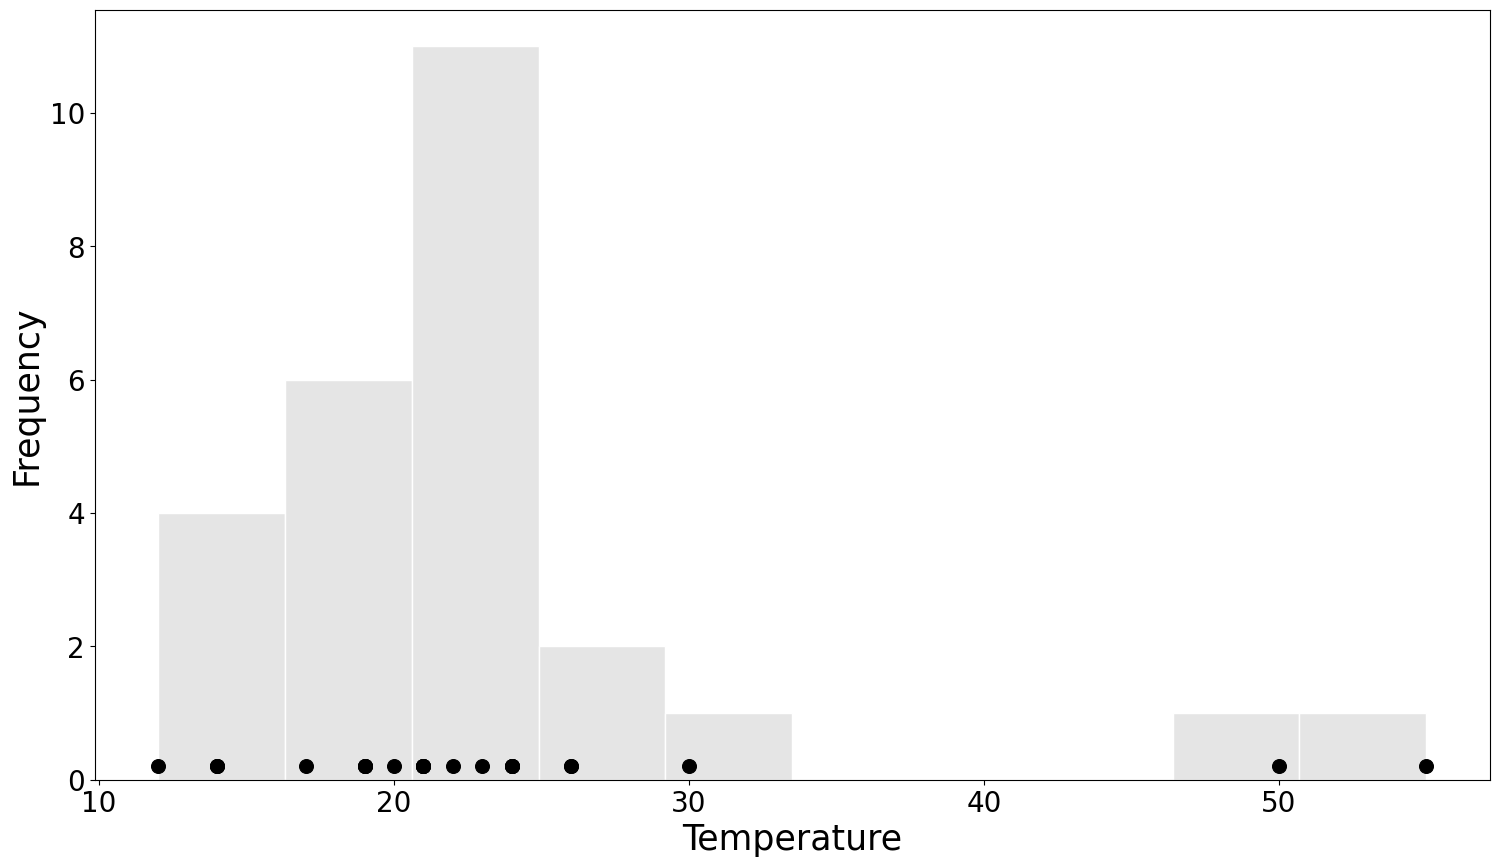

,0,1
perception_method,50,55.0
z_score_2_5_method,50,55.0
z_score_3_method,55,NaN
mad_method,50,55.0
iqr_method,50,55.0


In [3]:
data = np.array([12, 14, 14, 14, 17, 19, 19, 19, 19, 20,
                 21, 21, 21, 21, 21, 22, 23, 24, 24, 24,
                 24, 26, 26, 30, 50, 55])

save_path = image_save_path + 'temperatures1.png'
plot_data(data, save_path, save_switch=image_save_switch, balls_height=0.2,
          x_label='Temperature', y_label='Frequency')
apply_methods(data)

## Synthetic temperatures + outliers + additional normal - MAD failure

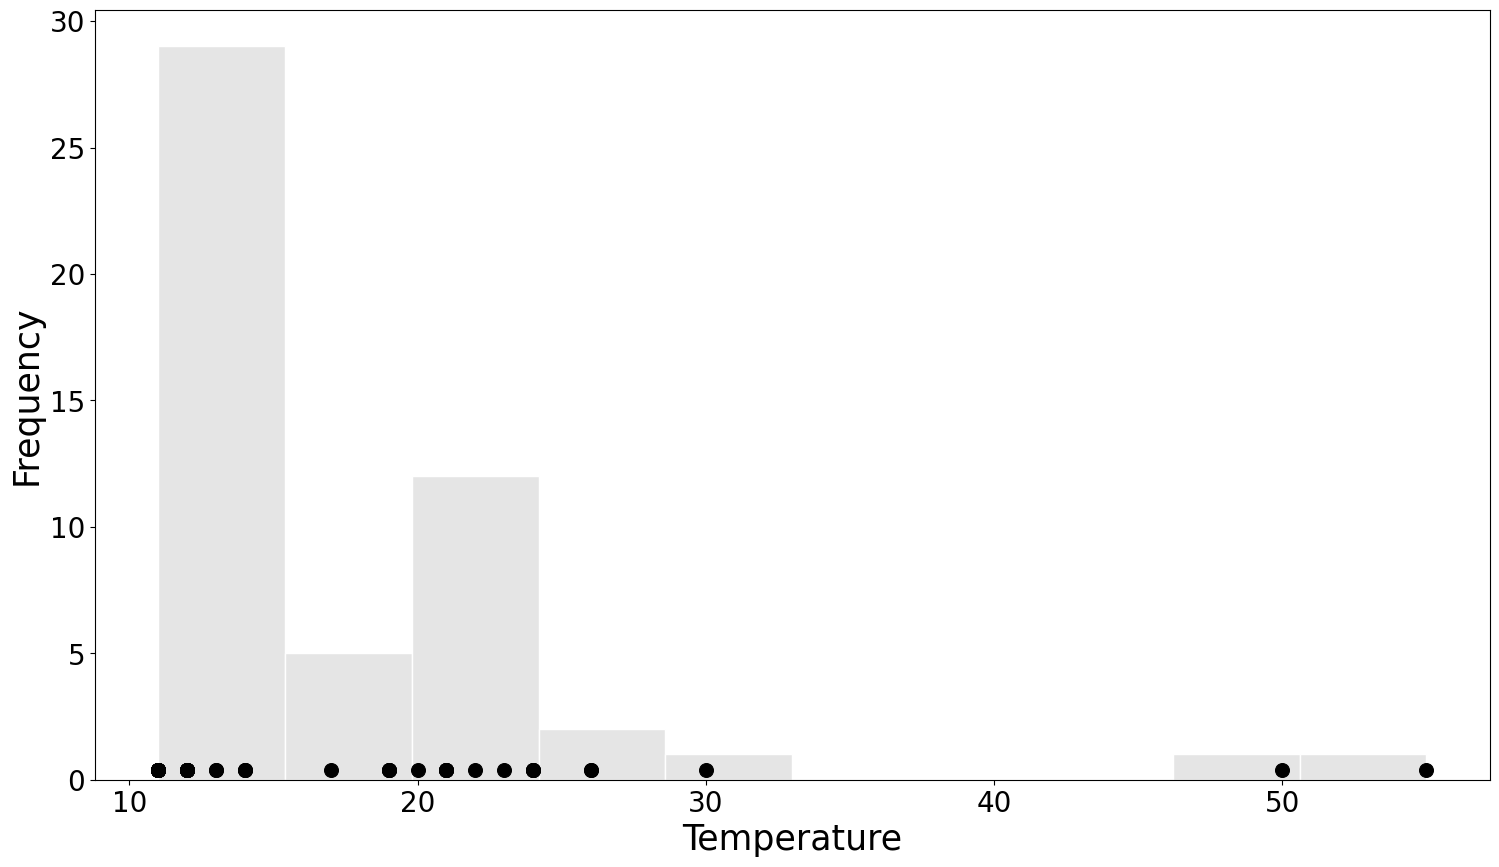

,0,1,2,3,4,5,6,7,8
perception_method,50,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
z_score_2_5_method,50,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
z_score_3_method,50,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mad_method,24,24,24.0,24.0,26.0,26.0,30.0,50.0,55.0
iqr_method,50,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# %% Synthetic temperatures + outliers + additional normal - MAD failure


data = np.array([11,
                 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13,
                 14, 14, 14, 17, 19, 19, 19, 19, 20, 21, 21, 21, 21, 21, 22, 23, 24, 24, 24, 24, 26, 26, 30,
                 50, 55,

                 ])

save_path = image_save_path + 'temperatures2.png'
plot_data(data, save_path, save_switch=image_save_switch, balls_height=0.4,
          x_label='Temperature', y_label='Frequency')
apply_methods(data)

## Lead data 

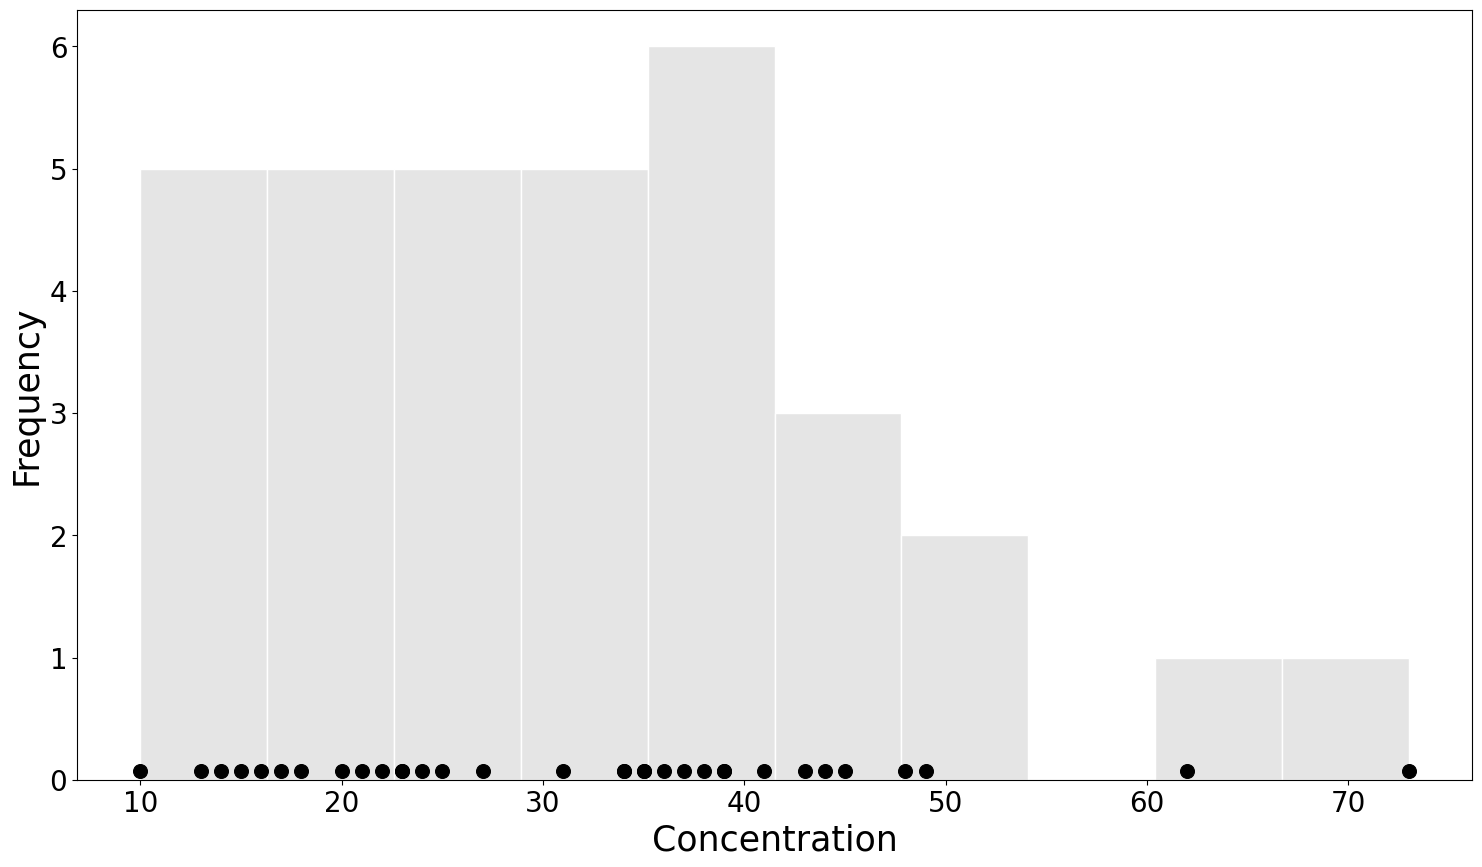

,0
perception_method,73.0
z_score_2_5_method,73.0
z_score_3_method,NaN
mad_method,NaN
iqr_method,73.0


In [5]:
# %% Lead Concentration
data = np.sort(np.array([10, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 23, 24,
                         25, 27, 31, 34, 34, 35, 35, 36, 37, 38, 39, 39, 41,
                         43, 44, 45, 48, 49, 62, 73]))


save_path = image_save_path + 'lead_exposure.png'
plot_data(data, save_path, save_switch=image_save_switch, balls_height=0.07,
          x_label='Concentration', y_label='Frequency')
apply_methods(data)

## Fluid Voltages 30v

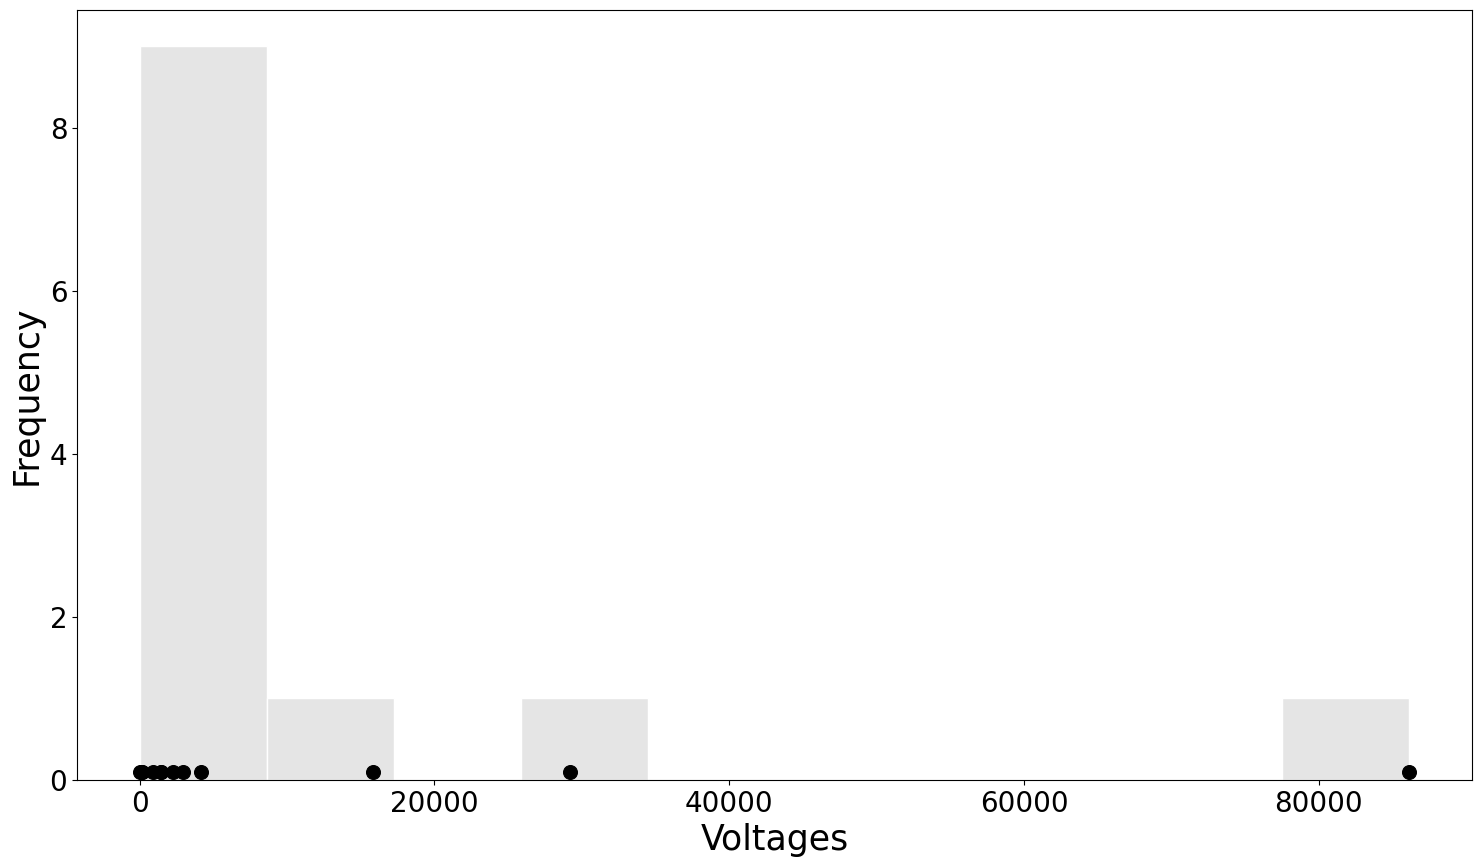

,0,1,2
perception_method,86100,NaN,NaN
z_score_2_5_method,86100,NaN,NaN
z_score_3_method,86100,NaN,NaN
mad_method,15800,29200.0,86100.0
iqr_method,29200,86100.0,NaN


In [6]:
# %% fluid_voltages_30v - breakdown of insulating fluid volatages
# Taken from: Boris Iglewicz and David C. Hoaglin. How to Detect and Handle
# Outliers, ASQC basic references in quality control, ASQC Quality Press,
# 1993. (The dataset has extreme outliers and the set is very small so that
# affect Perception, Z-scores and IQR methods). An example of masking.
data = np.array([
                50, 134, 187, 882, 1450, 1470, 2290,
                2930, 4180, 15800, 29200, 86100,
                ])

save_path = image_save_path + 'voltages_30.png'
plot_data(data, save_path, save_switch=False, balls_height=0.1,
          x_label='Voltages', y_label='Frequency')
apply_methods(data)

## Fluid Voltages 30v with replication of inliers only

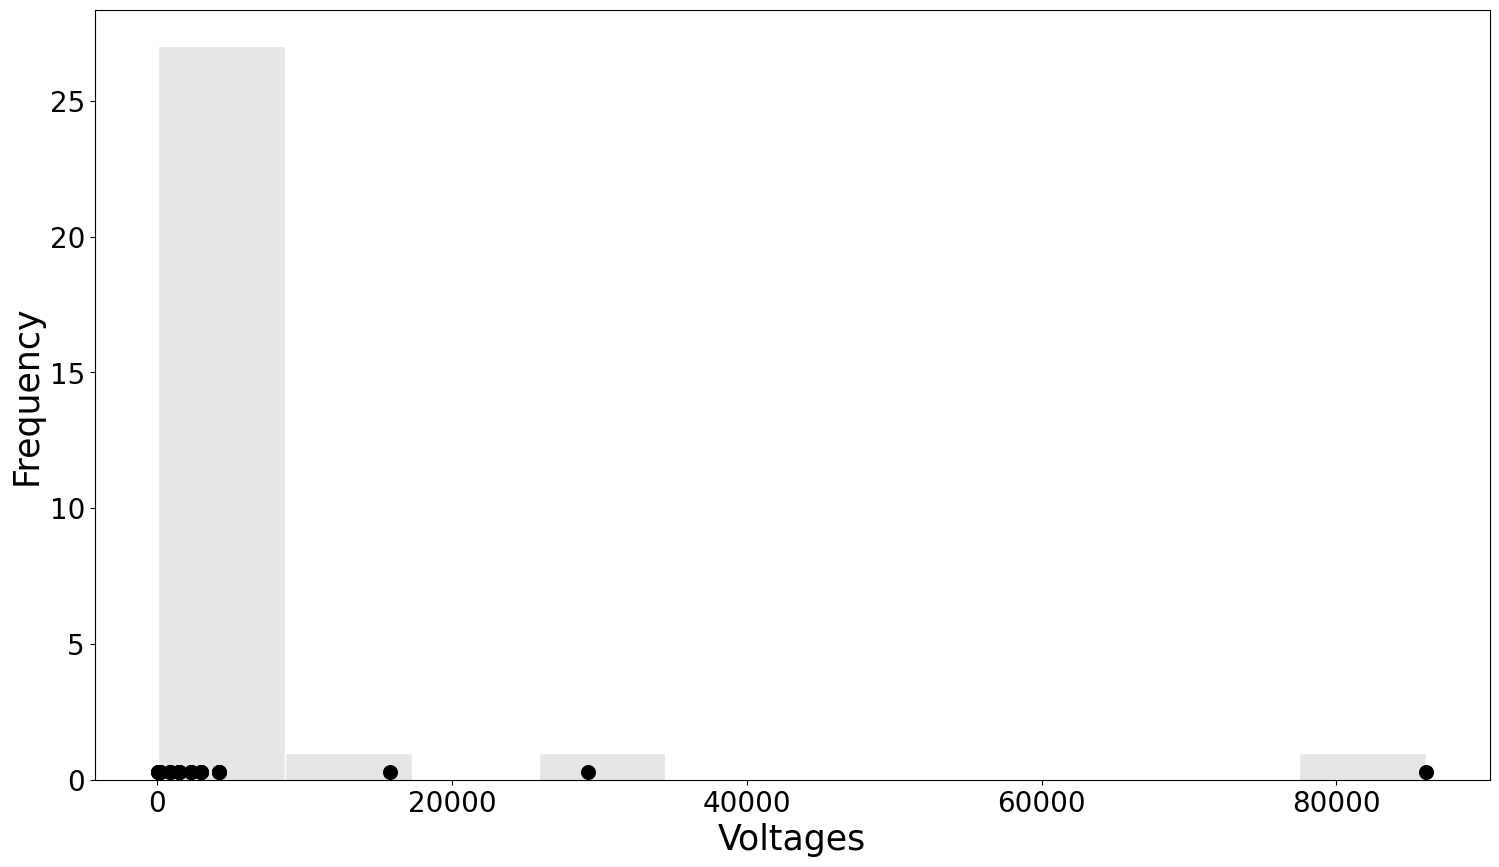

,0,1,2
perception_method,15800,29200.0,86100.0
z_score_2_5_method,86100,NaN,NaN
z_score_3_method,86100,NaN,NaN
mad_method,15800,29200.0,86100.0
iqr_method,15800,29200.0,86100.0


In [7]:
# %% fluid voltages 30v with replication of inliers only. This reduces
# the masking affect for perception algorithm, thereby reducing false
# negatives, but can potentially increase false positives.
data = np.array([
                50, 134, 187, 882, 1450, 1470, 2290,
                2930, 4180, 15800, 29200, 86100,

                50, 134, 187, 882, 1450, 1470, 2290,
                2930, 4180,

                50, 134, 187, 882, 1450, 1470, 2290,
                2930, 4180,
                ])

save_path = image_save_path + 'voltages_30_2.png'
plot_data(data, save_path, save_switch=False, balls_height=0.3,
          x_label='Voltages', y_label='Frequency')
apply_methods(data)


## Engineering data


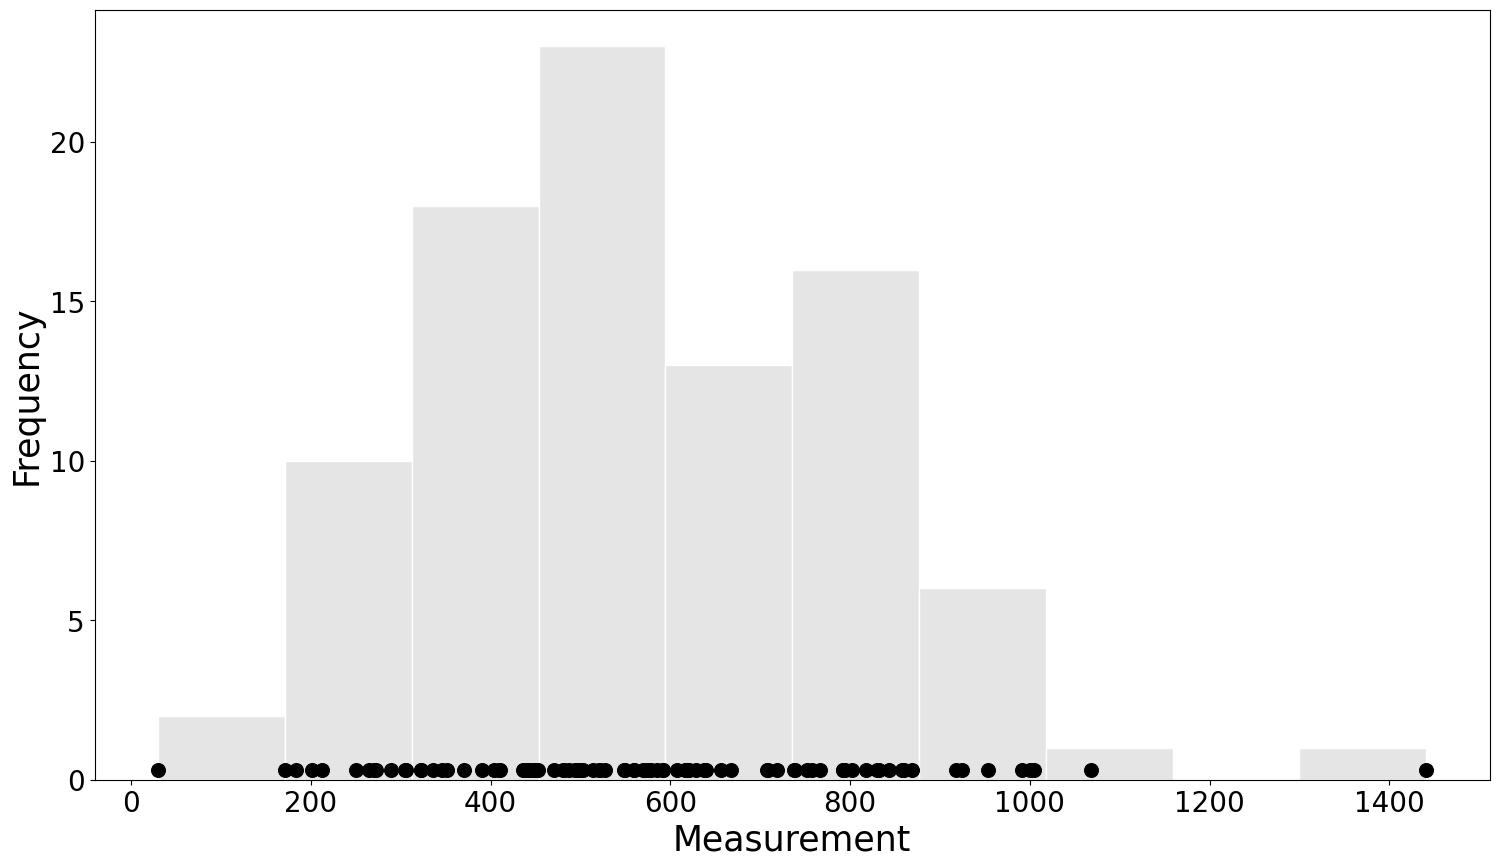

,0,1,2
perception_method,30,1068.0,1441.0
z_score_2_5_method,1441,NaN,NaN
z_score_3_method,1441,NaN,NaN
mad_method,1441,NaN,NaN
iqr_method,1441,NaN,NaN


In [8]:
# %% Engineering data
# Taken from: NIST. Engineering statistics handbook. Technical report, U.S.
# Department of Commerce,
# 2012. URL https://books.google.co.uk/books?id=v-XXjwEACAAJ.
data = np.array([30,
                 171, 184, 201, 212, 250, 265, 270, 272, 289, 305, 306,
                 322, 322, 336, 346, 351, 370, 390, 404, 409, 411, 436, 437,
                 439, 441, 444, 448, 451, 453, 470, 480, 482, 487, 494, 495,
                 499, 503, 514, 521, 522, 527, 548, 550, 559, 560, 570, 572,
                 574, 578, 585, 592, 592, 607, 616, 618, 621, 629, 637, 638,
                 640, 656, 668, 707, 709, 719, 737, 739, 752, 758, 766, 792,
                 792, 794, 802, 818, 830, 832, 843, 858, 860, 869, 918, 925,
                 953, 991, 1000, 1005,
                 1068, 1441])

save_path = image_save_path + 'engineer_stats.png'
plot_data(data, save_path, save_switch=False, balls_height=0.3,
          x_label='Measurement', y_label='Frequency')
apply_methods(data)

## Galton heights 

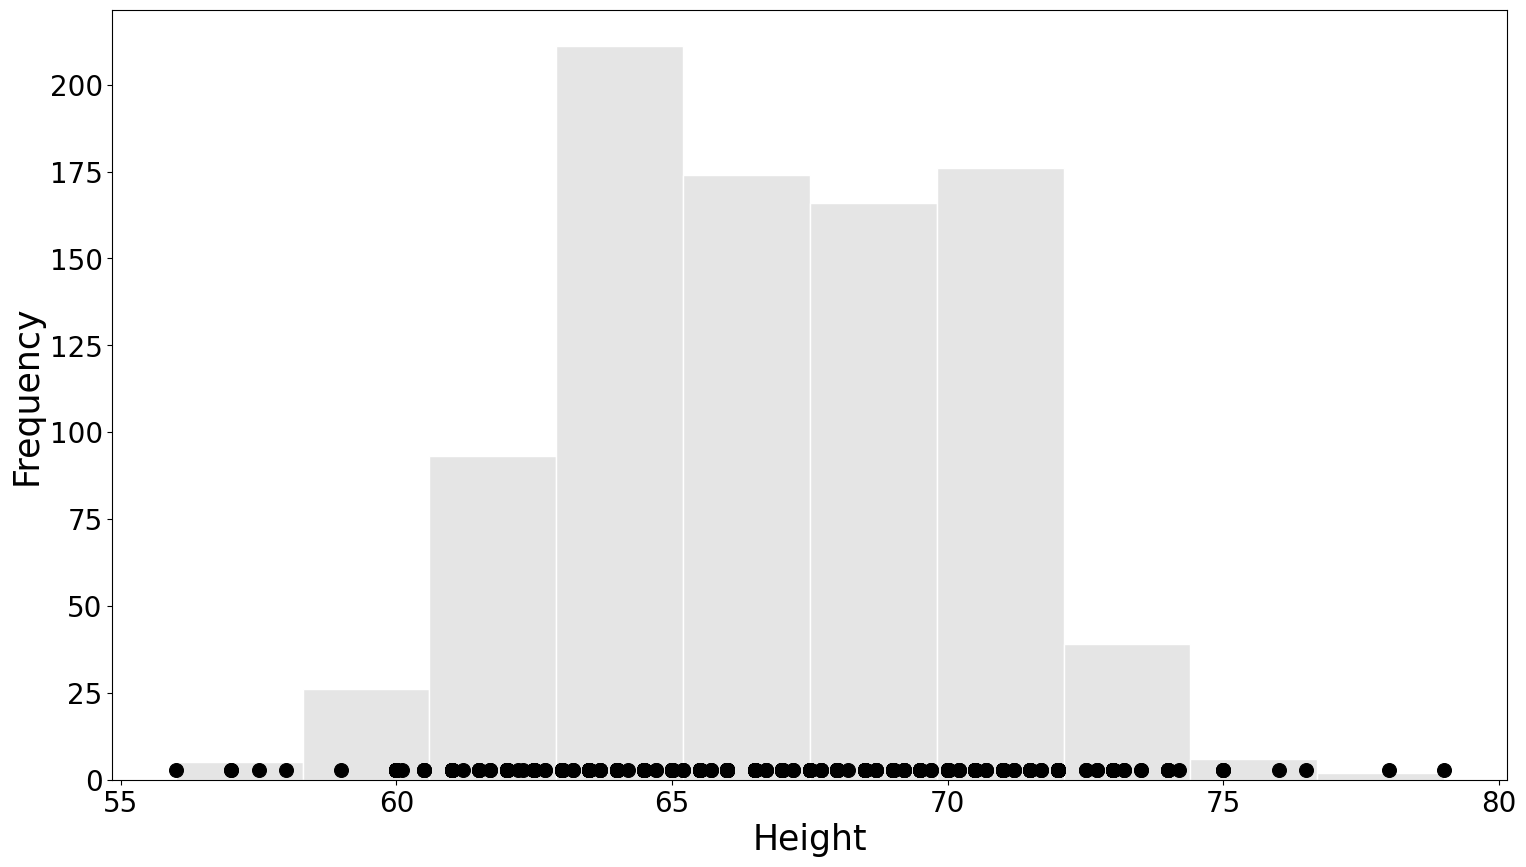

,0,1,2,3,4,5,6,7
perception_method,56.0,57.0,57.0,57.5,76.0,76.5,78.0,79.0
z_score_2_5_method,56.0,57.0,57.0,57.5,76.0,76.5,78.0,79.0
z_score_3_method,56.0,78.0,79.0,NaN,NaN,NaN,NaN,NaN
mad_method,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iqr_method,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# %% Galton heights
galton_height_path = "../data/Galton.txt"
g_df = pd.read_csv(galton_height_path, sep='\t', lineterminator='\r')
data = g_df['Height'].values

save_path = image_save_path + 'galton_heights.png'
plot_data(data, save_path, save_switch=image_save_switch, balls_height=2.8,
          x_label='Height', y_label='Frequency')
apply_methods(data)

# Some more examples 

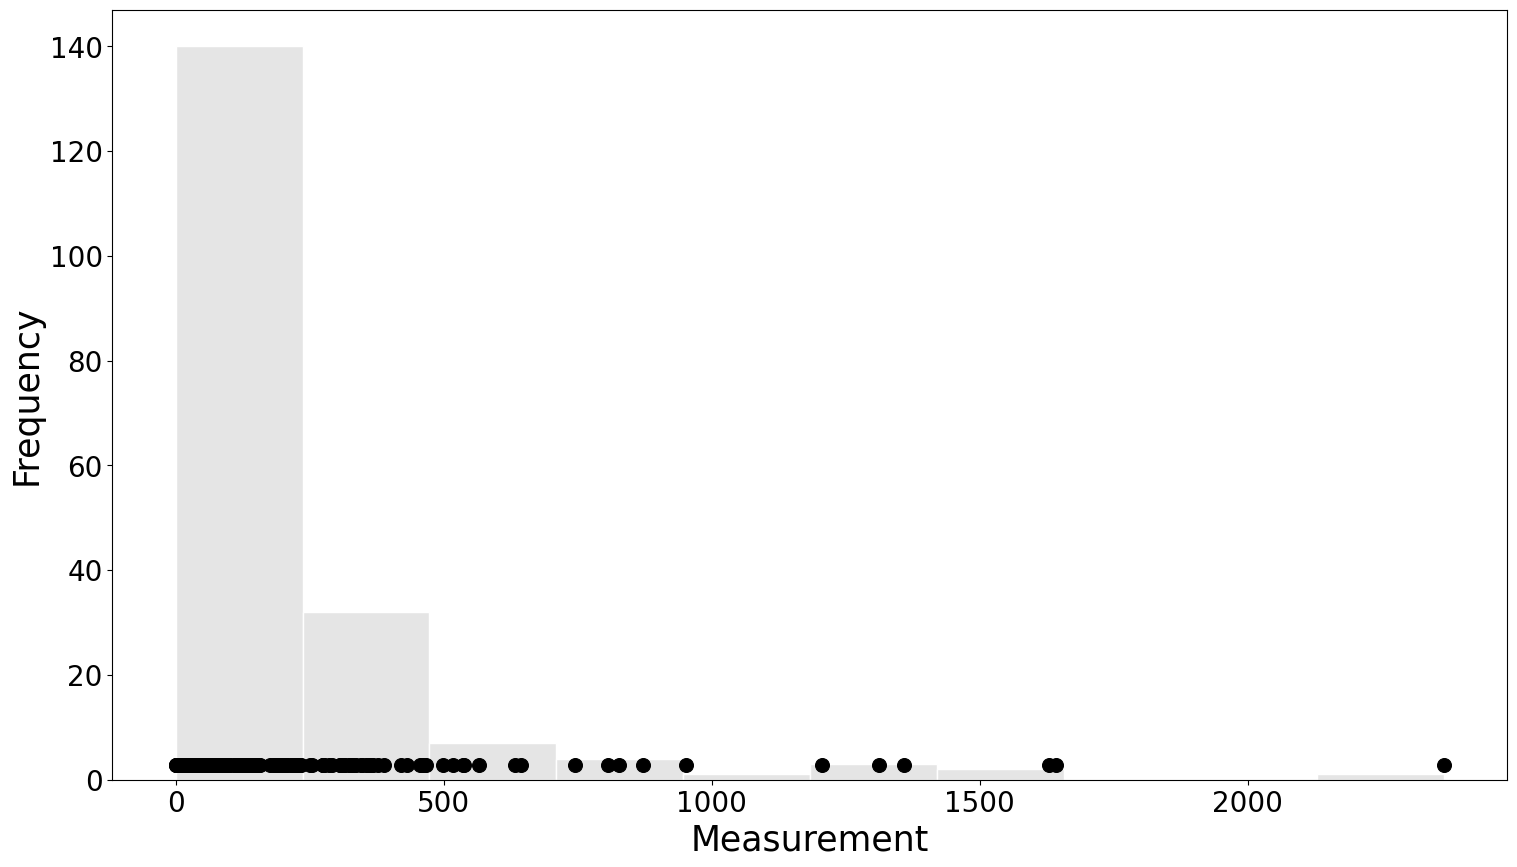

,0,1,2,3,4,5,6,7,8,9,10,11,12
perception_method,632,644,745,806,826,871,952.0,1205.0,1312.0,1358.0,1630.0,1643.0,2366.0
z_score_2_5_method,1205,1312,1358,1630,1643,2366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
z_score_3_method,1205,1312,1358,1630,1643,2366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mad_method,632,644,745,806,826,871,952.0,1205.0,1312.0,1358.0,1630.0,1643.0,2366.0
iqr_method,632,644,745,806,826,871,952.0,1205.0,1312.0,1358.0,1630.0,1643.0,2366.0


In [10]:
# coal_path = "coal.txt"
# x = pd.read_csv(coal_path, delimiter=r"\s+", header=None)
# data = x.values.flatten()

data = np.array([ 157,  123,    2,  124,   12,    4,   10,  216,   80,   12,   33,
         66,  232,  826,   40,   12,   29,  190,   97,   65,  186,   23,
         92,  197,  431,   16,  154,   95,   25,   19,   78,  202,   36,
        110,  276,   16,   88,  225,   53,   17,  538,  187,   34,  101,
         41,  139,   42,    1,  250,   80,    3,  324,   56,   31,   96,
         70,   41,   93,   24,   91,  143,   16,   27,  144,   45,    6,
        208,   29,  112,   43,  193,  134,  420,   95,  125,   34,  127,
        218,    2,    0,  378,   36,   15,   31,  215,   11,  137,    4,
         15,   72,   96,  124,   50,  120,  203,  176,   55,   93,   59,
        315,   59,   61,    1,   13,  189,  345,   20,   81,  286,  114,
        108,  188,  233,   28,   22,   61,   78,   99,  326,  275,   54,
        217,  113,   32,  388,  151,  361,  312,  354,  307,  275,   78,
         17, 1205,  644,  467,  871,   48,  123,  456,  498,   49,  131,
        182,  255,  194,  224,  566,  462,  228,  806,  517, 1643,   54,
        326, 1312,  348,  745,  217,  120,  275,   20,   66,  292,    4,
        368,  307,  336,   19,  329,  330,  312,  536,  145,   75,  364,
         37,   19,  156,   47,  129, 1630,   29,  217,    7,   18, 1358,
       2366,  952,  632])

save_path = None
plot_data(data, save_path, save_switch=False, balls_height=2.8,
          x_label='Measurement', y_label='Frequency')
apply_methods(data)

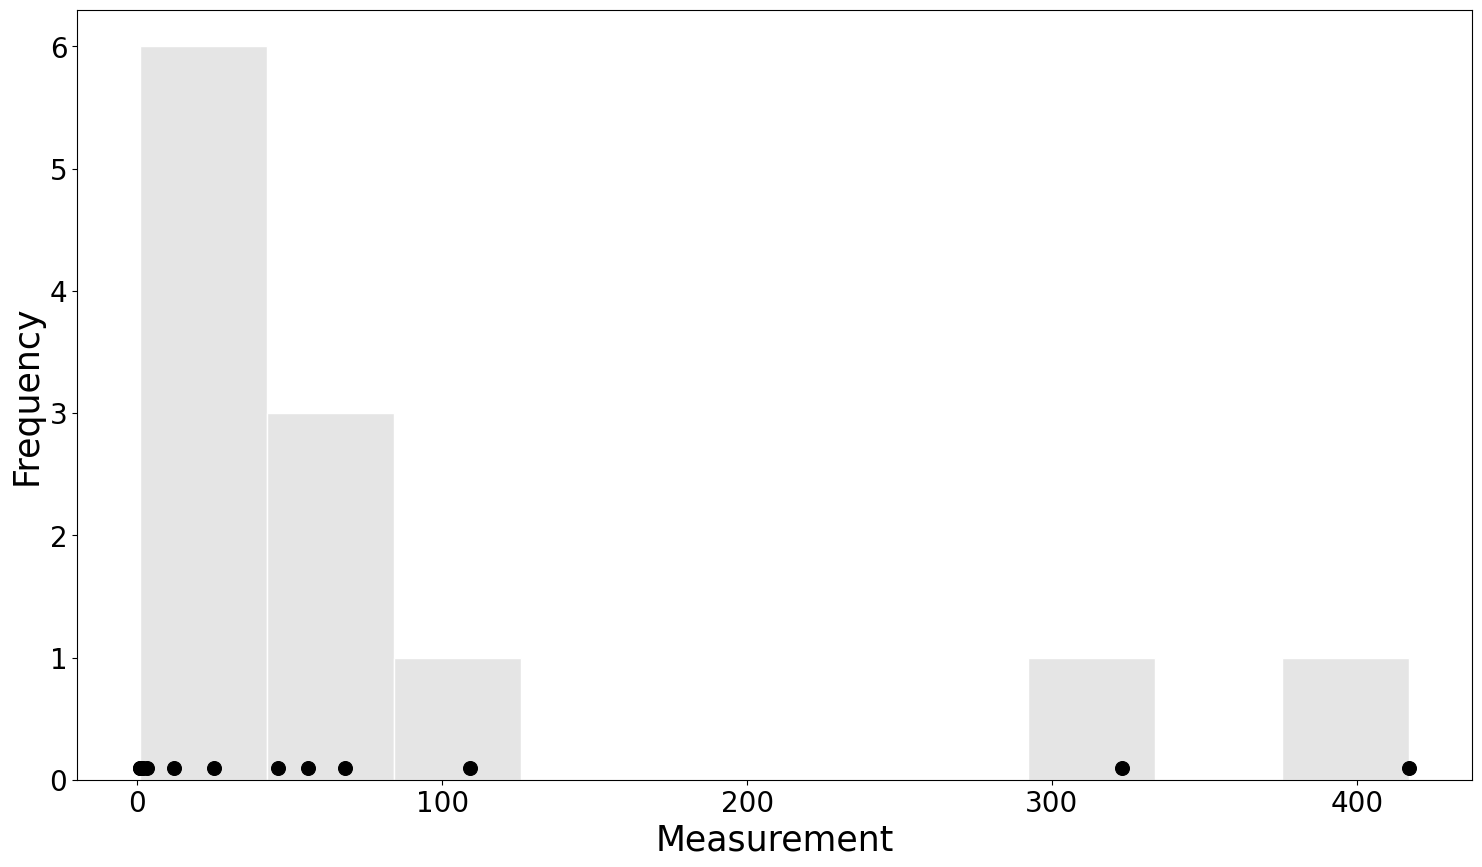

,0,1
perception_method,323.0,417.0
z_score_2_5_method,417.0,NaN
z_score_3_method,NaN,NaN
mad_method,323.0,417.0
iqr_method,323.0,417.0


In [11]:
# 40V data - breakdown of insulating fluid volatages
data = np.array([1,1,2,3,12,25,46,56,68,109,323,417])

save_path = None
plot_data(data, save_path, save_switch=False, balls_height=0.1,
          x_label='Measurement', y_label='Frequency')
apply_methods(data)

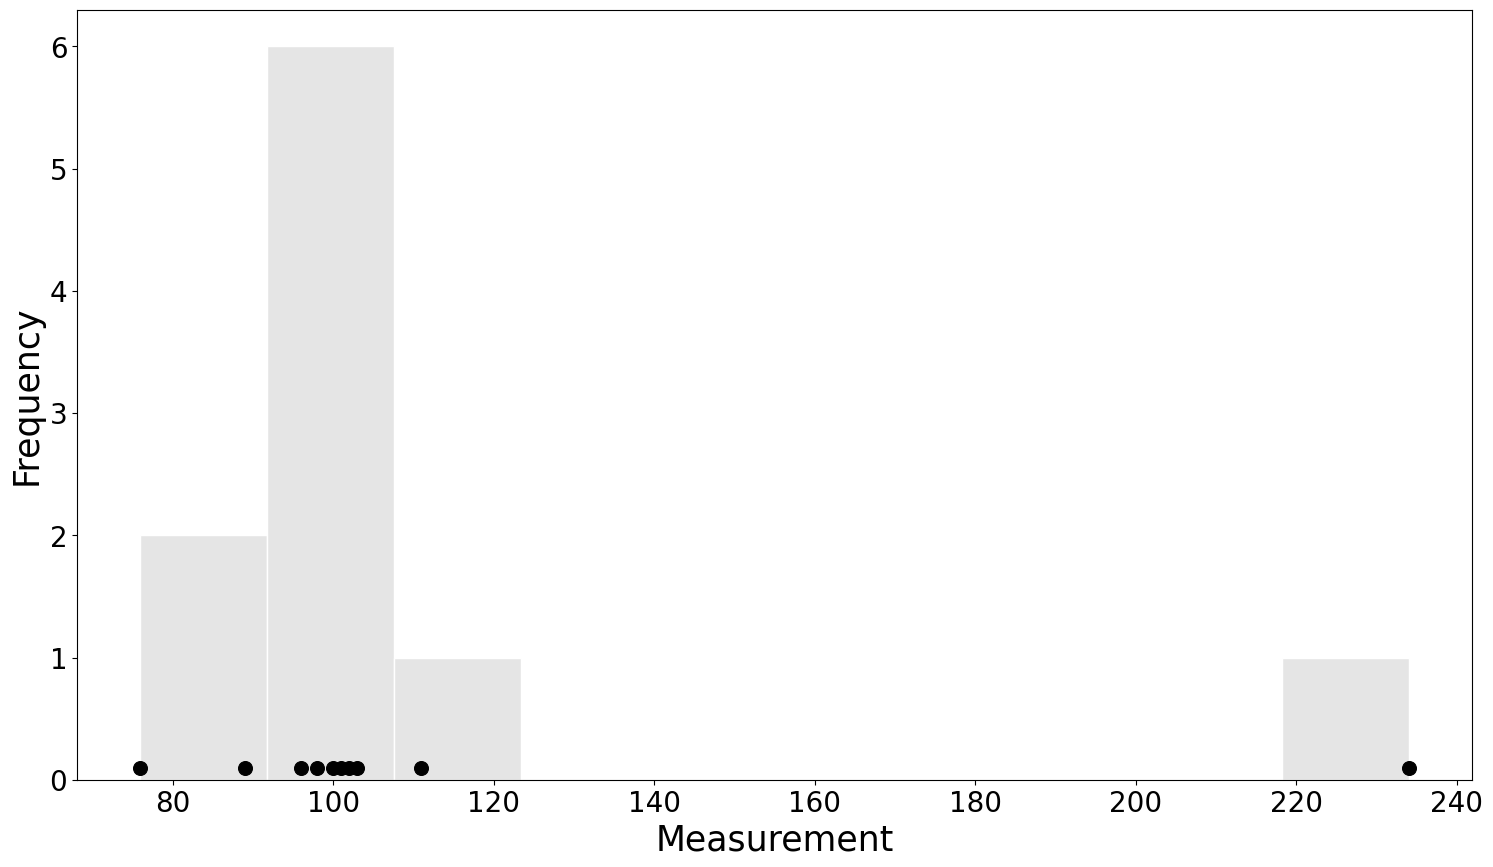

,0,1
perception_method,234.0,NaN
z_score_2_5_method,234.0,NaN
z_score_3_method,NaN,NaN
mad_method,76.0,234.0
iqr_method,76.0,234.0


In [12]:
# Taken from: Boris Iglewicz and David C. Hoaglin. How to Detect and Handle
# Outliers, ASQC basic references in quality control, ASQC Quality Press,
# 1993.

data = np.array([103, 96, 111, 76, 102, 98, 89, 234, 101, 100])
save_path = None
plot_data(data, save_path, save_switch=False, balls_height=0.1,
          x_label='Measurement', y_label='Frequency')
apply_methods(data)